### Train--Forward Pass and Backward Pass

#### 一、Forward Pass

##### 前向传播 = 神经网络根据输入，一层一层算出输出的过程
##### 只计算，不学习
每个神经元进行线性组合和非线性激活：
- 线性组合：神经元接受来自上一层的数据X，每个数据都会乘熵一个权重W（信息的重要性）加上偏置B(调整整体活跃度)
- 非线性激活：利用激活函数将数值压缩到0-1之间

In [1]:
import numpy as np

def relu(z):
    return np.maximum(0, z)

# 输入
x = np.array([[1], [2]])

# 第一层参数
W1 = np.array([[0.5, 0.2],
               [0.3, 0.7]])
b1 = np.array([[0.1], [0.2]])

# 前向传播
z1 = W1 @ x + b1
a1 = relu(z1)

print("隐藏层输出 a1:\n", a1)

隐藏层输出 a1:
 [[1. ]
 [1.9]]


#### 二、Backward Pass

##### 反向传播 = 根据预测误差，从后往前算梯度，更新权重，让模型越算越准

##### 核心：链式法则
误差对权重的影响 = 误差对输出的影响 × 输出对加权和的影响 × 加权和对权重的影响
- 计算损失函数：当前向传播给出预测值后，利用损失函数与真实答案进行对比，差距为损失
- 梯度计算：利用链式法则，从输出层开始，反向穿过每一层，计算每个权重对最终损失贡献了多少责任
- 梯度下降：利用梯度下降法，将梯度作为参数的更新方向，将梯度作为参数的更新幅度

In [ ]:
import numpy as np

def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return z > 0  # 导数：大于0为1，否则0

# 前向传播（已算过）
x = np.array([[1], [2]])
W1 = np.array([[0.5,0.2],[0.3,0.7]])
b1 = np.array([[0.1],[0.2]])
z1 = W1 @ x + b1
a1 = relu(z1)

# 输出层
W2 = np.array([[0.4, 0.6]])
b2 = np.array([[0.3]])
z2 = W2 @ a1 + b2
a2 = relu(z2)
y = np.array([[1]])



# 1. 输出层误差
dz2 = (a2 - y) * relu_deriv(z2)
dW2 = dz2 @ a1.T
db2 = dz2

# 2. 隐藏层误差
dz1 = (W2.T @ dz2) * relu_deriv(z1)
dW1 = dz1 @ x.T
db1 = dz1

# 3. 更新权重
lr = 0.1
W1 -= lr * dW1
b1 -= lr * db1
W2 -= lr * dW2
b2 -= lr * db2

print("更新后的W1:\n", W1)

更新后的W1:
 [[0.4664 0.1328]
 [0.2496 0.5992]]


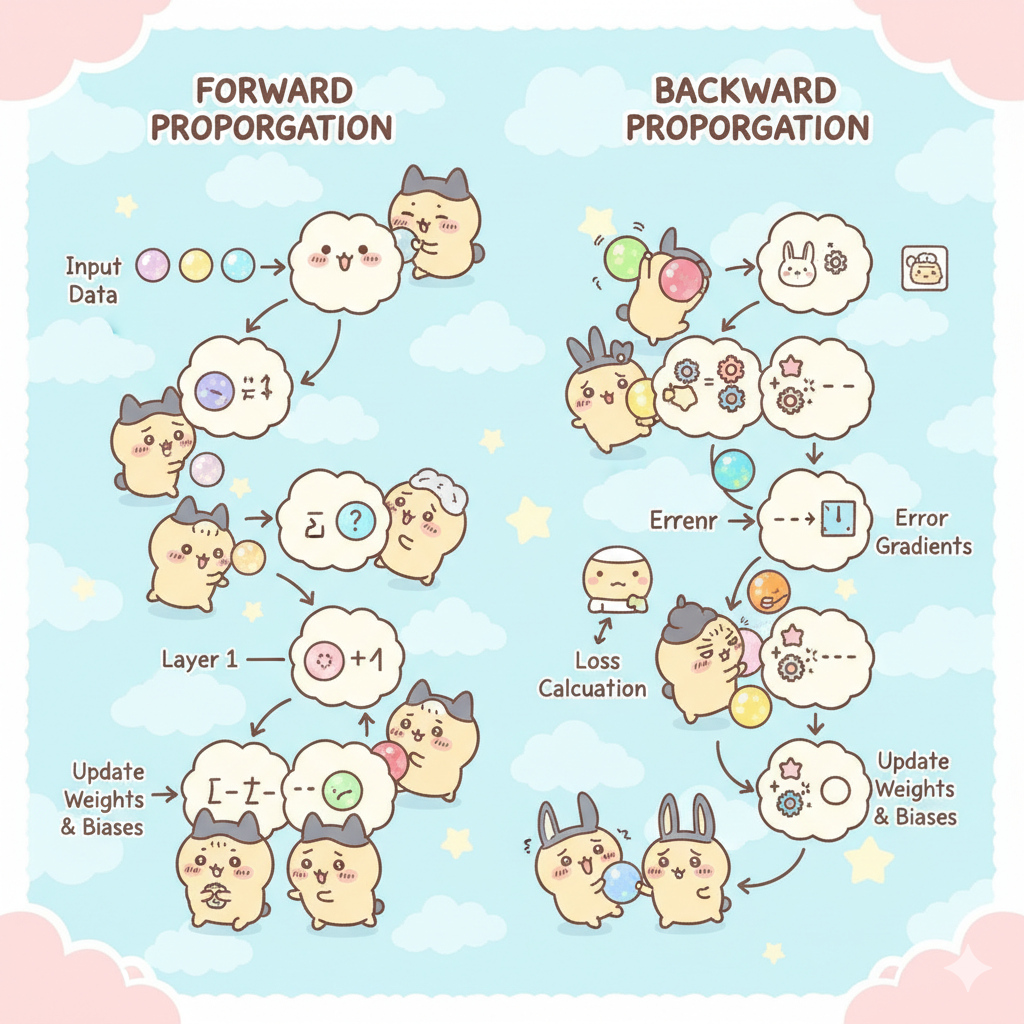